### confusion matrices

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from matplotlib.colors import TwoSlopeNorm

In [3]:
def create_confusion_matrix(data, species):
    """
    Creates a confusion matrix from detection results using GT derived from filename.

    Args:
        data: list of results entries from results.json
        species: list of species names in order of class indices

    Returns:
        cm: (num_classes + 1) x (num_classes + 1) confusion matrix
            Rows = ground truth classes
            Columns = predicted classes
            Last row = background FP
            Last column = missed GT (FN)
    """
    num_classes = len(species)
    cm = np.zeros((num_classes + 1, num_classes + 1), dtype=int)

    for entry in data:
        filename = entry["filename"]
        # Derive GT class from filename; fallback to last index if unknown
        row_index = next((i for i, sp in enumerate(species) if filename.startswith(sp)), num_classes)

        # True positives (correct predictions)
        for cls_id in entry["true_positives"]["classes"]:
            cm[row_index, cls_id] += 1

        # False negatives (missed GT objects)
        cm[row_index, num_classes] += len(entry["false_negatives"]["classes"])

        # False positives
        for cls_id in entry["false_positives"]["classes"]:
            if cls_id == row_index:
                # Background FP (wrong location for correct class)
                cm[num_classes, cls_id] += 1
            else:
                # Misclassification (wrong class)
                cm[row_index, cls_id] += 1

    return cm

def normalize_confusion_matrix(cm, axis=1):
    """
    Normalize a confusion matrix.

    Parameters
    ----------
    cm : list[list[int]] or np.ndarray
        The confusion matrix.
    axis : int
        Axis to normalize over:
        - 1 = rows (normalize by true class → each row sums to 1)
        - 0 = columns (normalize by predicted class → each column sums to 1)
        - None = normalize by total sum

    Returns
    -------
    np.ndarray
        Normalized confusion matrix (float values).
    """
    cm = np.array(cm, dtype=float)
    if axis is None:
        total = cm.sum()
        return cm / total if total > 0 else cm
    else:
        sums = cm.sum(axis=axis, keepdims=True)
        sums[sums == 0] = 1 
 # avoid division by zero
        return cm / sums
    
def plot_confusion_matrix(cm, species, output_path=None):

    # assume confusion_matrix and labels are already defined
    labels = species + ["background"]
    df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(8, 6))
    plt.imshow(df, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()

    # tick labels
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)

    # annotate counts
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, df.iat[i, j],
                    ha="center", va="center",
                    color="white" if df.iat[i, j] > df.values.max()/2 else "black")

    plt.ylabel("True Species")
    plt.xlabel("Predicted Species")
    plt.tight_layout()
    if output_path: plt.savefig(output_path)
    plt.show()




def give_confusion_infos(file, output_path=None):
    with open(file, "r") as f:
        data = json.load(f)

    species = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]
    cm = create_confusion_matrix(data, species)

    print("Confusion Matrix with FP/FN (last row = FP, last col = FN):\n", cm)

    # Row-normalized (recall per class)
    norm_cm_row = normalize_confusion_matrix(cm, axis=1)
    # Column-normalized (precision per class)
    norm_cm_col = normalize_confusion_matrix(cm, axis=0)

    labels = species + ["background"]

    # ✅ use constrained_layout to avoid tight_layout warning
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, norm_cm, title in zip(
        axes,
        [norm_cm_row, norm_cm_col],
        ["Row-normalized (Recall per class)", "Column-normalized (Precision per class)"]
    ):
        df = pd.DataFrame(np.round(norm_cm, 2), index=labels, columns=labels)
        im = ax.imshow(df, interpolation="nearest", cmap="Blues")
        ax.set_title(title)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_ylabel("True Species")
        ax.set_xlabel("Predicted Species")

        # annotate cells
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(
                    j, i, f"{df.iat[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if df.iat[i, j] > df.values.max()/2 else "black",
                    fontsize=8
                )

    # shared colorbar (works fine with constrained_layout)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Normalized Value")
    if output_path: plt.savefig(output_path)
    plt.show()
    return norm_cm_row, norm_cm_col


In [4]:
def plot_confusion_matrix_differences(norm_cm_row_1, norm_cm_row_2,
                                      norm_cm_col_1, norm_cm_col_2,
                                      species, output_path = None):
    """
    Plot the differences between two sets of normalized confusion matrices
    (row- and column-normalized) with intuitive coloring:

    - Diagonal ↑ = green (improvement), ↓ = red (worse)
    - Off-diagonal ↑ = red (worse), ↓ = green (improvement)
    - Color range automatically scaled to actual data range
    """

    labels = species + ["background"]

    # Compute differences
    diff_row = np.round(norm_cm_row_2 - norm_cm_row_1, 3)
    diff_col = np.round(norm_cm_col_2 - norm_cm_col_1, 3)

    # Make figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, diff_cm, title in zip(
        axes,
        [diff_row, diff_col],
        ["Δ Row-normalized (Recall change)", "Δ Column-normalized (Precision change)"]
    ):
        df = pd.DataFrame(diff_cm, index=labels, columns=labels)

        # Invert off-diagonal meaning (since increases in misclassifications are bad)
        adjusted = df.copy()
        for i in range(len(labels)):
            for j in range(len(labels)):
                if i != j:
                    adjusted.iat[i, j] = -adjusted.iat[i, j]

        # Compute color limits dynamically
        vmin, vmax = adjusted.values.min(), adjusted.values.max()
        vlim = max(abs(vmin), abs(vmax))  # symmetric around zero

        # Use a centered diverging colormap: red↔white↔green
        norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)
        im = ax.imshow(adjusted, interpolation="nearest", cmap="RdYlGn", norm=norm)

        ax.set_title(title)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_ylabel("True Species")
        ax.set_xlabel("Predicted Species")

        # Annotate numeric values (+/-)
        for i in range(len(labels)):
            for j in range(len(labels)):
                val = df.iat[i, j]
                if abs(val) > 0.005:
                    ax.text(
                        j, i, f"{val:+.2f}",
                        ha="center", va="center",
                        color="black",
                        fontsize=8
                    )

    # Shared colorbar
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Green = improvement, Red = degradation", rotation=270, labelpad=20)
    if output_path: plt.savefig(output_path)
    plt.show()


species = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]


### Quality of image processed pseudo labels measured against ground truth
low recall, but ok precision

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 605    0    0    0  625]
 [   0  645    0    0  473]
 [   0    0    0    0    0]
 [   0    0    0  822 1615]
 [ 163   88    0  194    0]]


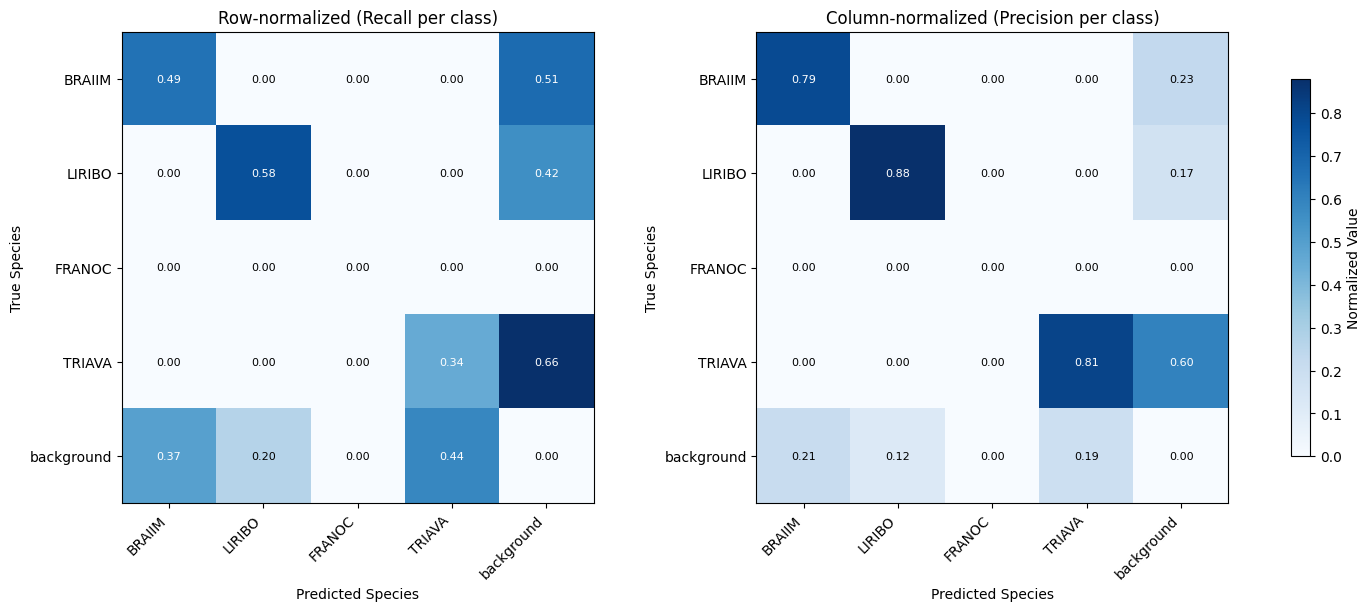

In [10]:
#Test image processing on test set
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/image_procv2.json"
c1, c2 = give_confusion_infos(file, output_path = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/image_procv2_vs_testset.png")

### Quality of model trained on these pseudo labels measured against ground truth
recall improved, precision changed somewhat

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1045   63    0    0  534]
 [  41 1029    0    5  230]
 [   0    0    0    0    0]
 [   5   42    0  771 1850]
 [ 190  192    0   36    0]]


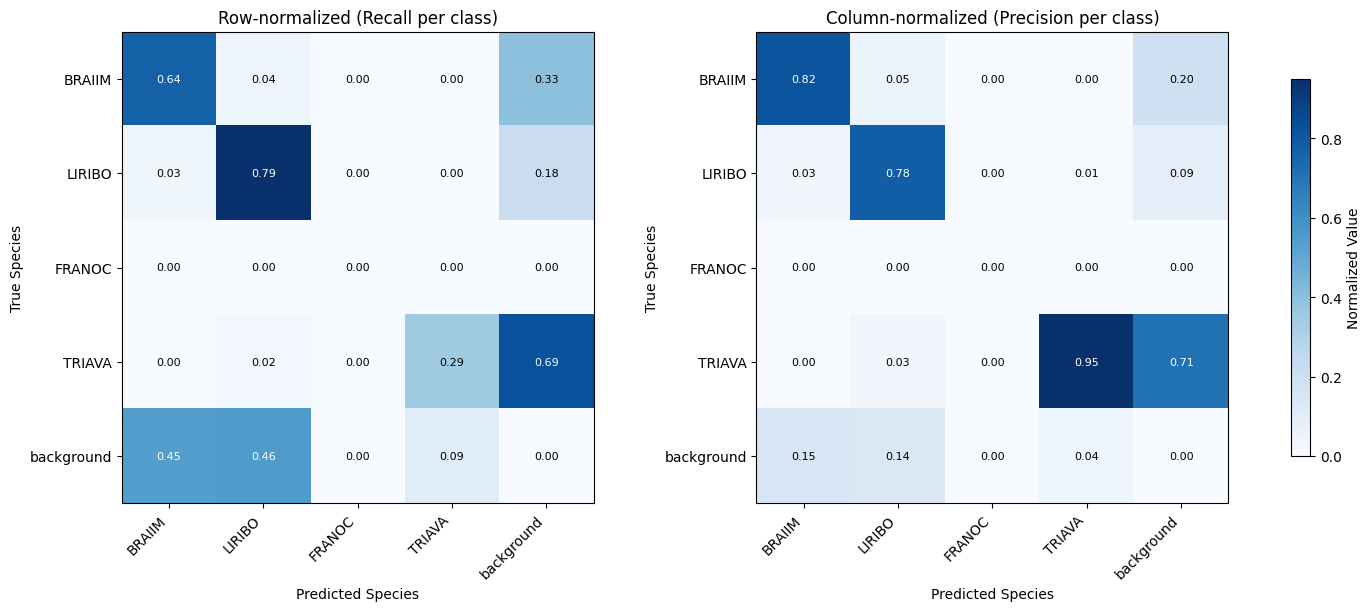

In [11]:
#test results of first iteration
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/first_iteration_train9.json"
c3, c4 = give_confusion_infos(file, output_path="/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/first_iteration_train9_vs_testset.png")

### Quality of model trained on the pseudo labels measure against image processed test set labels
high recall: sticks to the pseudo labels

lowered precision: did not stick to the pseudo label rules? (and compare precision on ground truth: these are sensical rules)

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[665  60   0   0 103]
 [ 38 669   0   4  64]
 [  0   0   0   0   0]
 [  6  48   0 436 580]
 [415 422   0 255   0]]


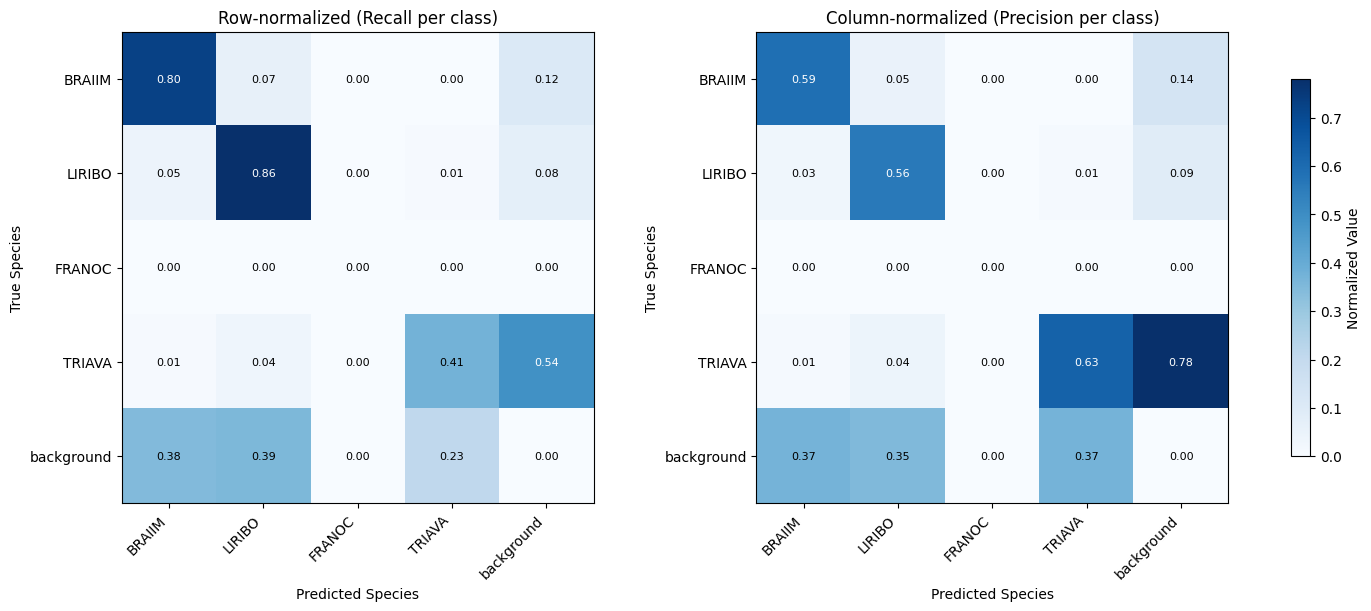

In [12]:
#test results of first iteration
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/first_iteration_train9_on_pseudolabeled_testset.json"
c5, c6 = give_confusion_infos(file, output_path = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/first_iteration_train9_vs_pseudolabeled_testset.png")

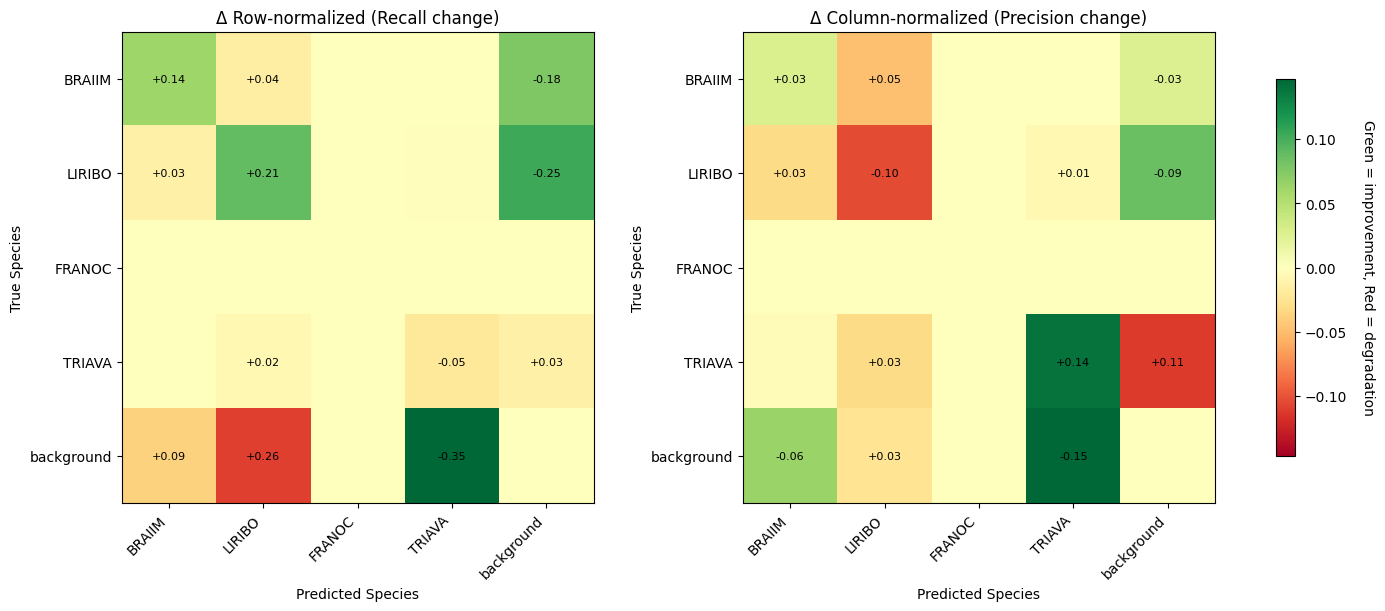

In [ ]:
#Difference of segmented labels and first training
plot_confusion_matrix_differences(c1,c3, c2, c4, species, 
                                  output_path="/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/03_imag_proc_vs_first.png")

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 961   59    0    6  618]
 [  11 1016    0   13  243]
 [   0    0    0    0    0]
 [   1   14    0  747 1874]
 [ 152  119    0   47    0]]


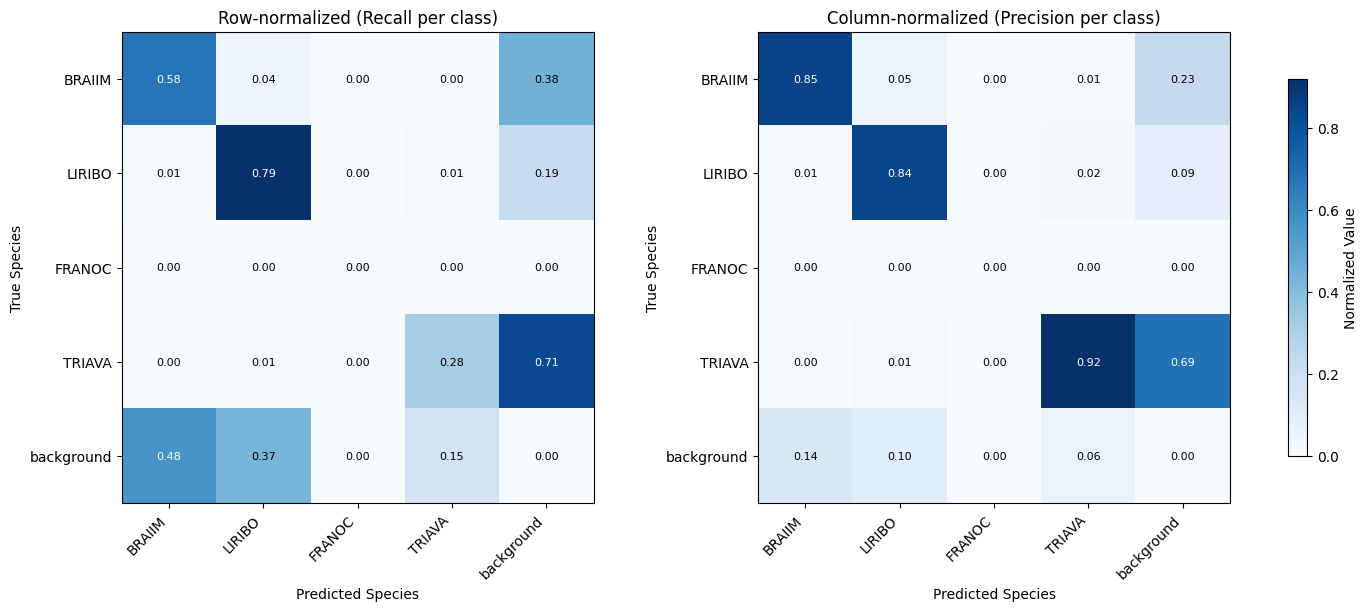

In [ ]:
#test results of second iteration unweighted
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/second_iteration_unweighted_train1.json"
c1,c2 = give_confusion_infos(file)

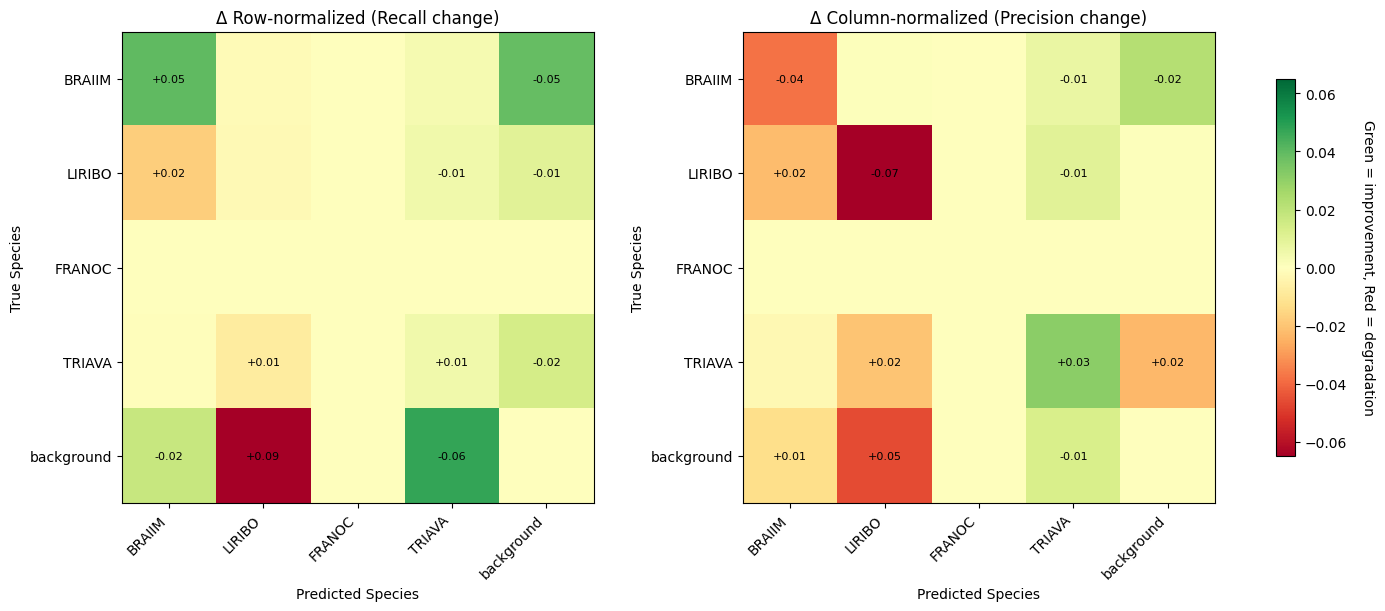

In [ ]:
#Difference of irst training and unweighted second
plot_confusion_matrix_differences(c1,c3, c2, c4, species, 
                                  output_path="/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/04a_second_vs_first_unweighted.png")

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 990   37    0    4  589]
 [  12  995    0   20  264]
 [   0    0    0    0    0]
 [   1    8    0  894 1727]
 [ 178   98    0   92    0]]


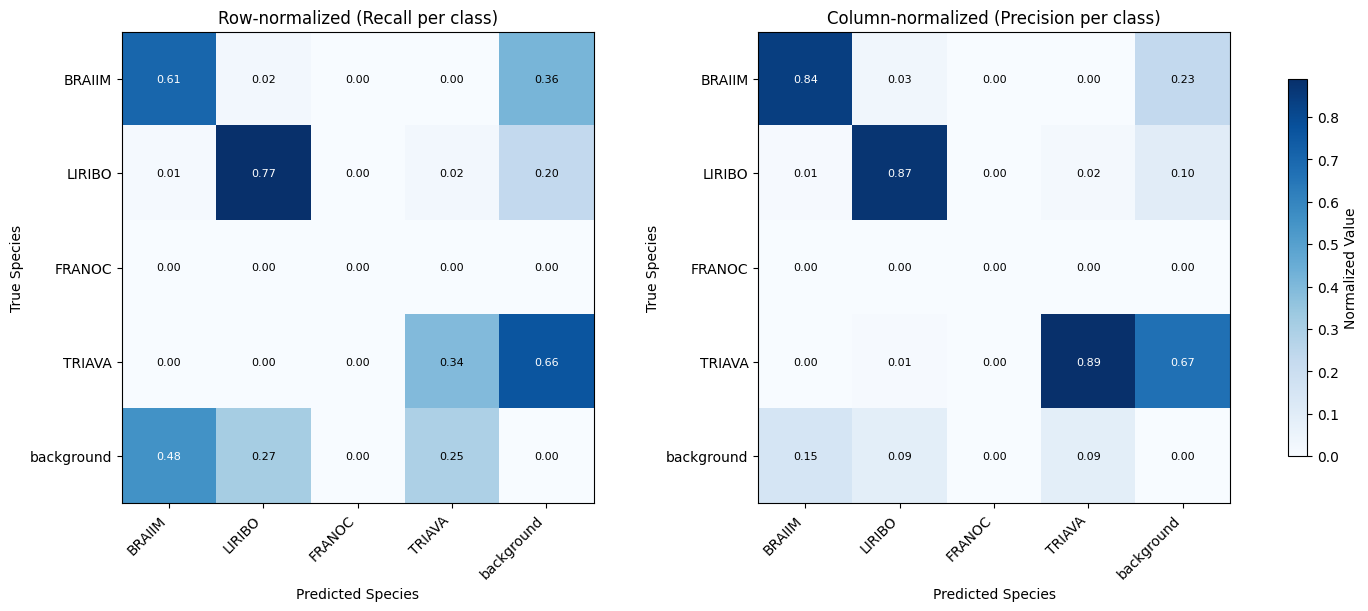

In [ ]:
#test results of second iteration weighted
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/second_iteration_weighted_train4.json"
c1,c2 = give_confusion_infos(file)

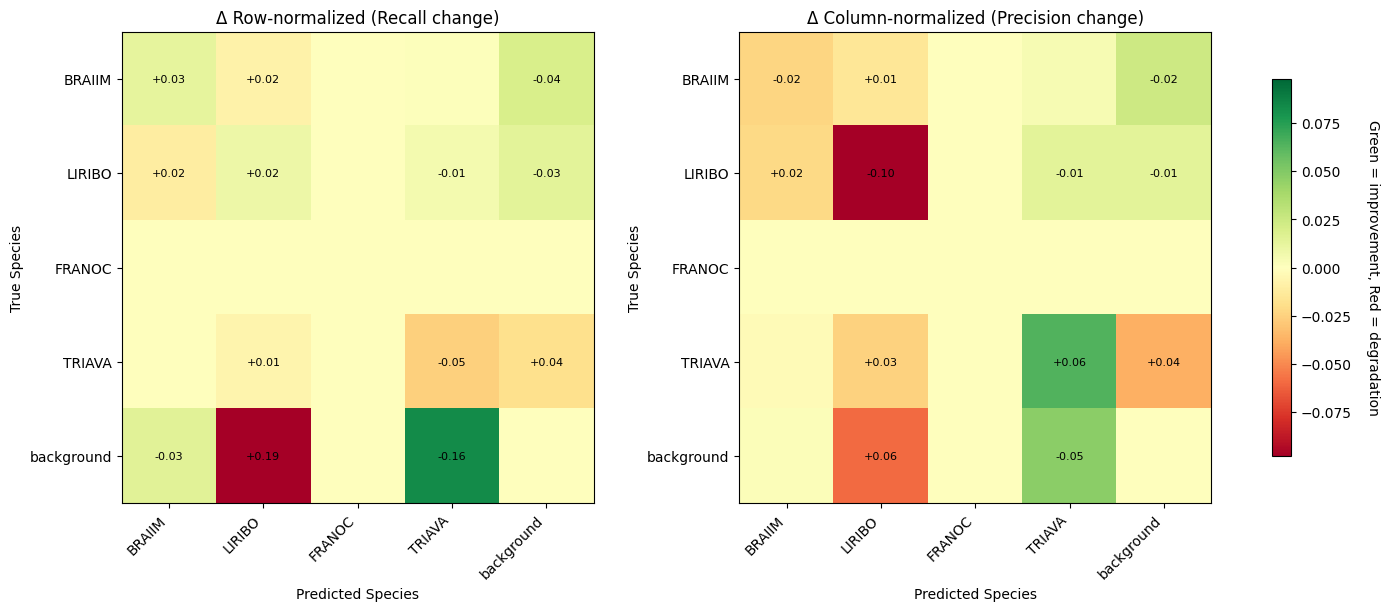

In [ ]:
#Difference of first training and second weighted
plot_confusion_matrix_differences(c1,c3, c2, c4, species, 
                                  output_path="/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/04b_second_vs_first_weighted.png")

### Seems like  a tradeoff between prec/recall

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 961   59    0    6  618]
 [  11 1016    0   13  243]
 [   0    0    0    0    0]
 [   1   14    0  747 1874]
 [ 152  119    0   47    0]]


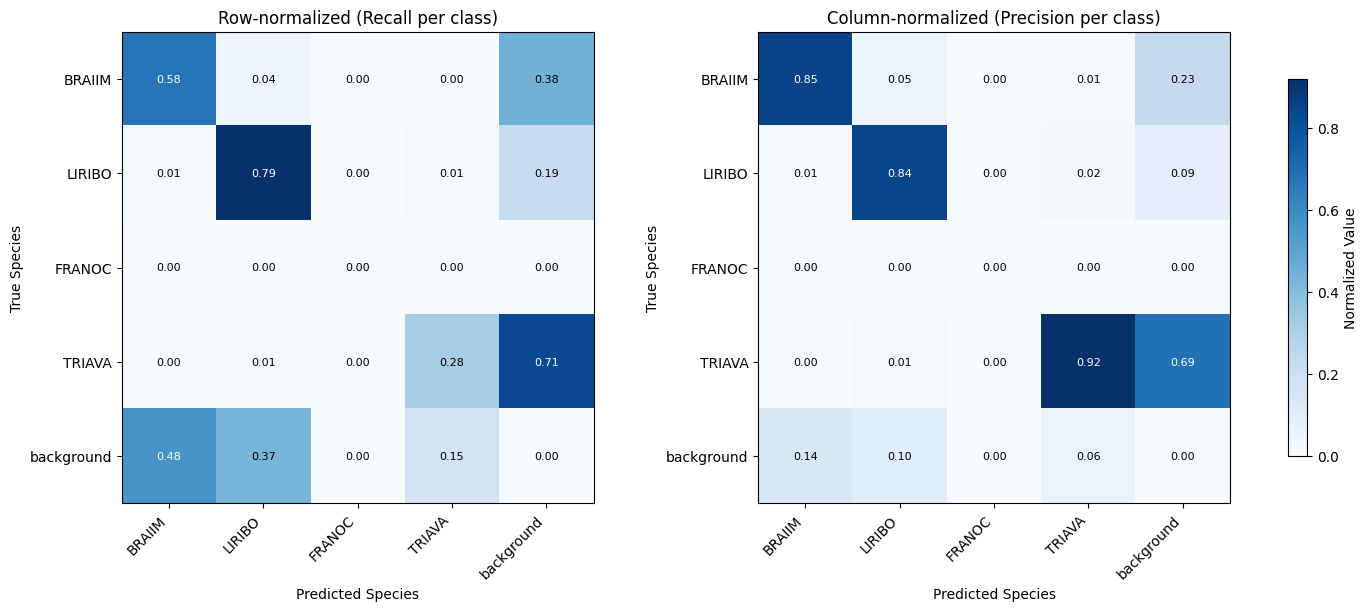

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 990   37    0    4  589]
 [  12  995    0   20  264]
 [   0    0    0    0    0]
 [   1    8    0  894 1727]
 [ 178   98    0   92    0]]


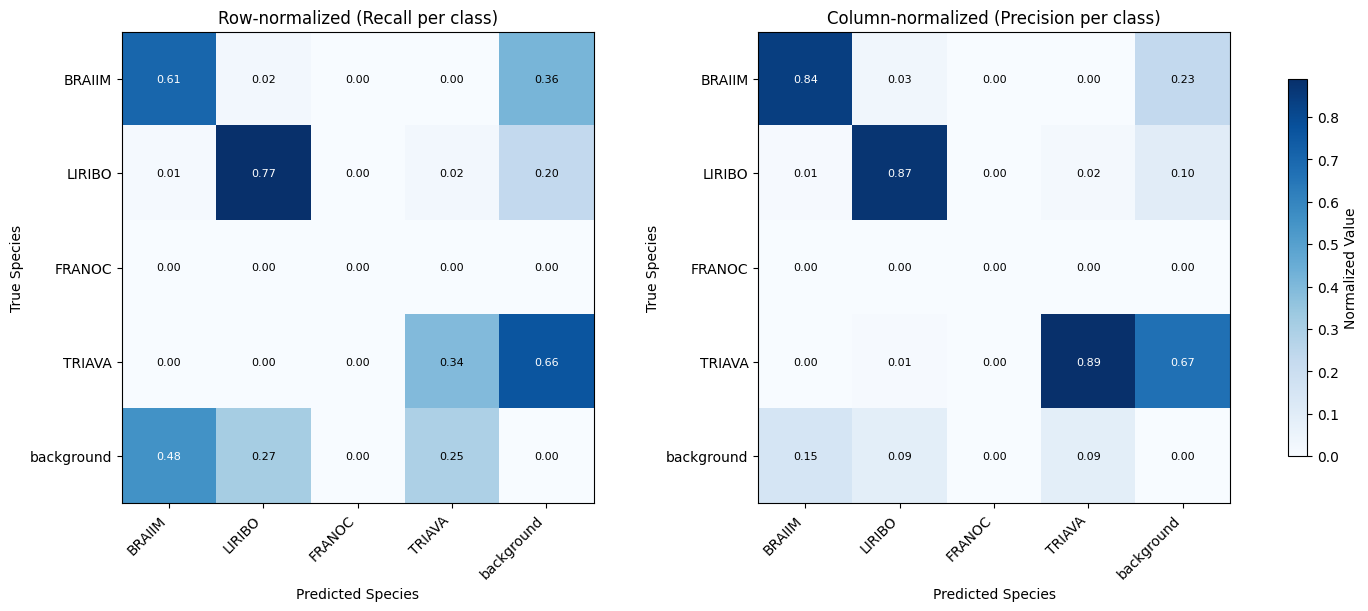

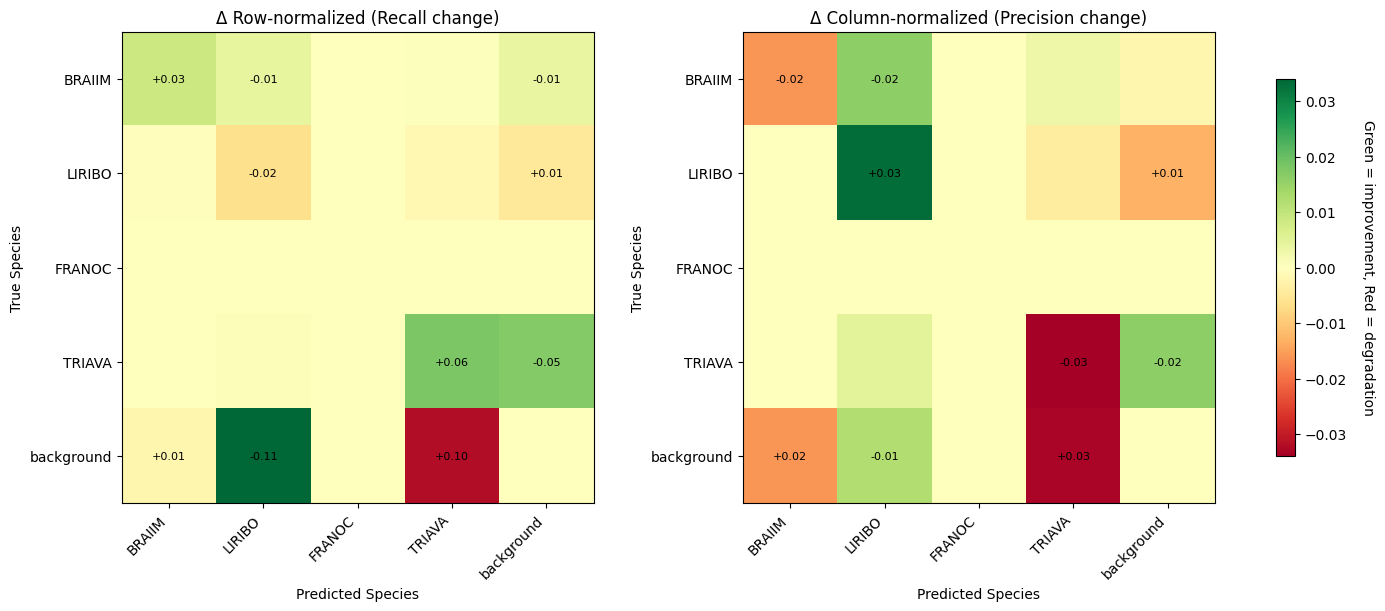

In [ ]:
#differences of second unweighted and weighted
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/second_iteration_unweighted_train1.json"
c1,c2 = give_confusion_infos(file)
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/second_iteration_weighted_train4.json"
c3,c4 = give_confusion_infos(file)
plot_confusion_matrix_differences(c1,c3, c2, c4, species, 
                                  output_path="/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/04c_unweighted_vs_weighted.png")

### More iterations on weighted pseudo labels


Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 896   30    0    2  683]
 [  10  942    0   12  317]
 [   0    0    0    0    0]
 [   1    6    0  735 1886]
 [ 158   85    0   54    0]]


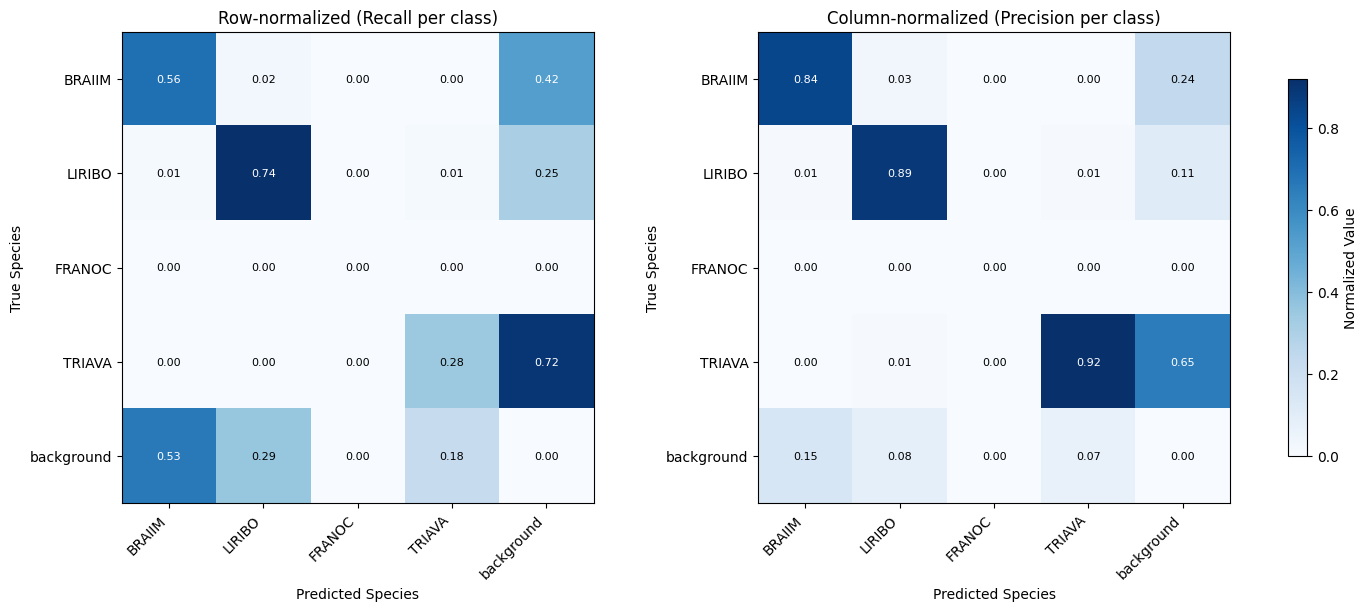

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 780   34    0    5  799]
 [  17  939    0    7  320]
 [   0    0    0    0    0]
 [   2   10    0  617 2004]
 [ 114   92    0   35    0]]


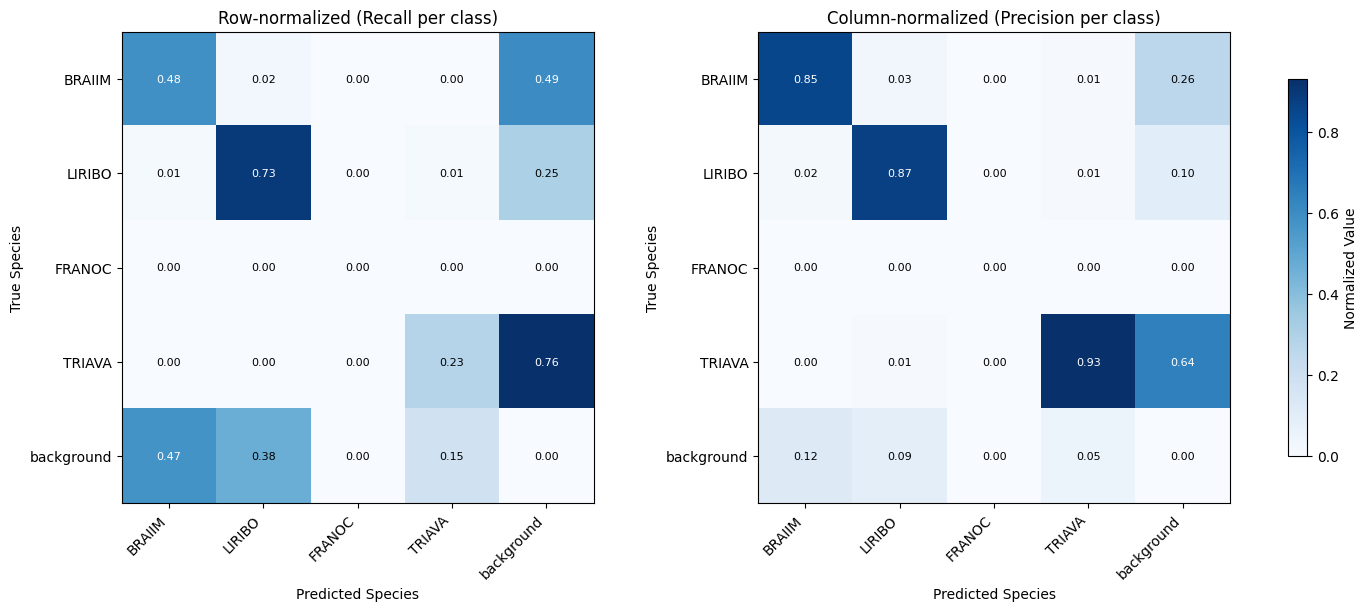

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 930   24    0    6  649]
 [  66  911    0   18  348]
 [   0    0    0    0    0]
 [   1    3    0  694 1927]
 [ 153   80    0   45    0]]


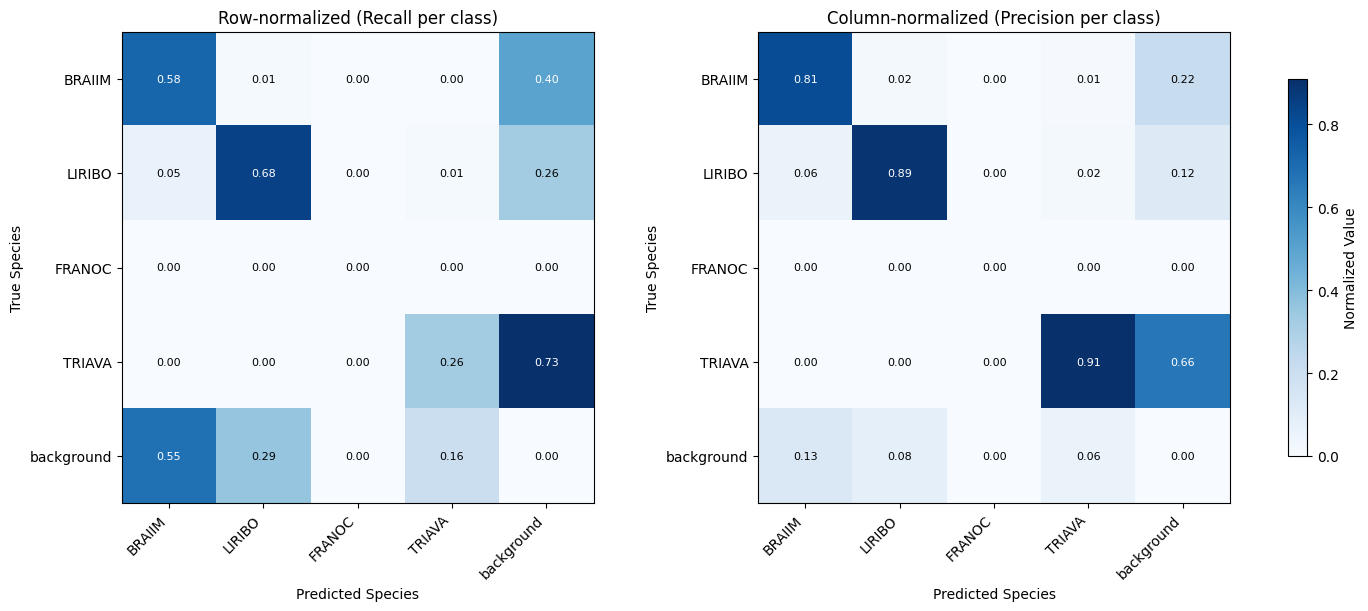

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 901   24    0    2  678]
 [  17  890    0   10  369]
 [   0    0    0    0    0]
 [   5    5    0  639 1982]
 [ 156   70    0   31    0]]


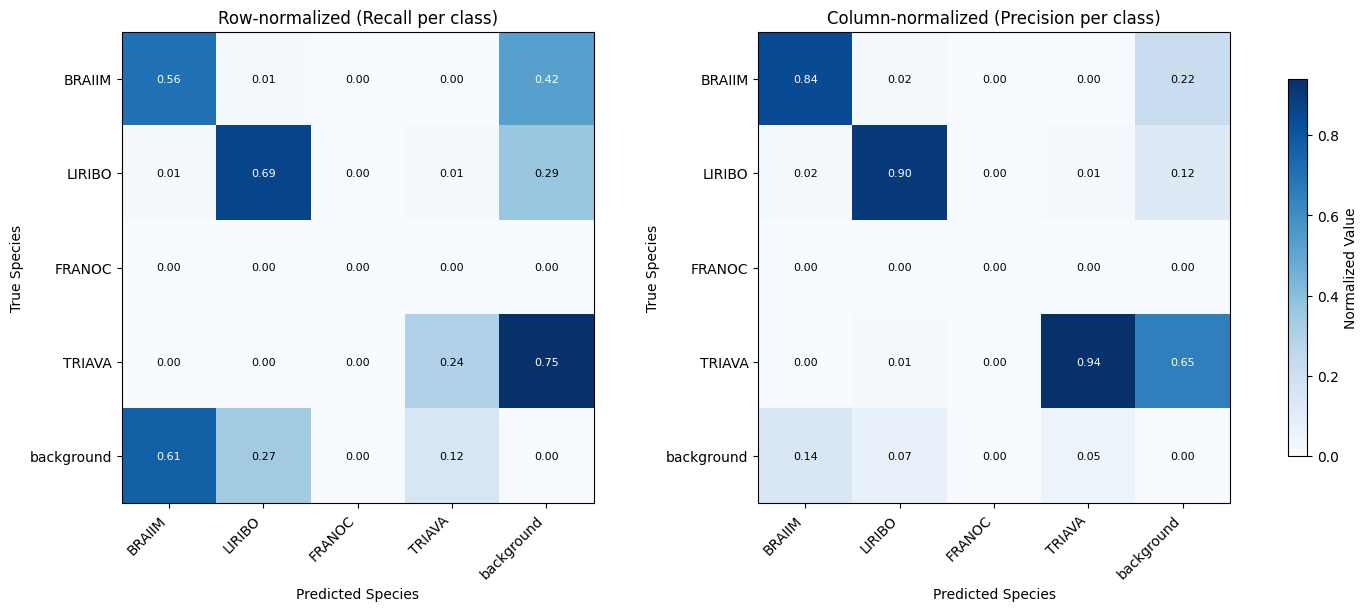

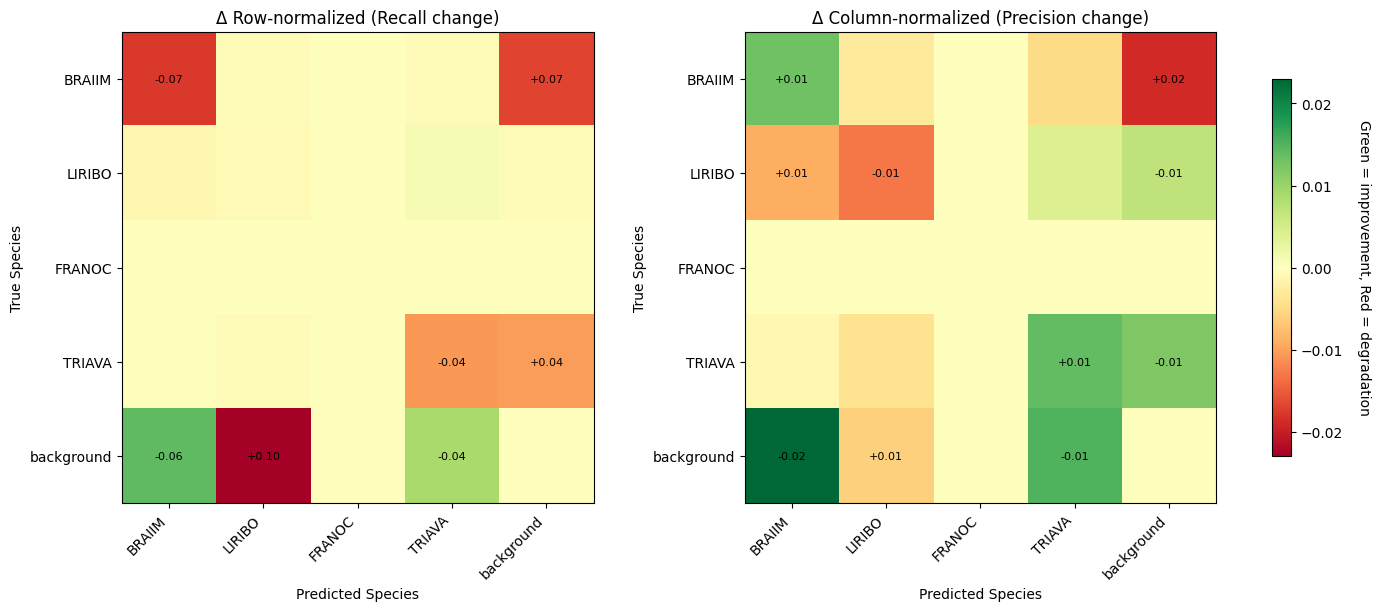

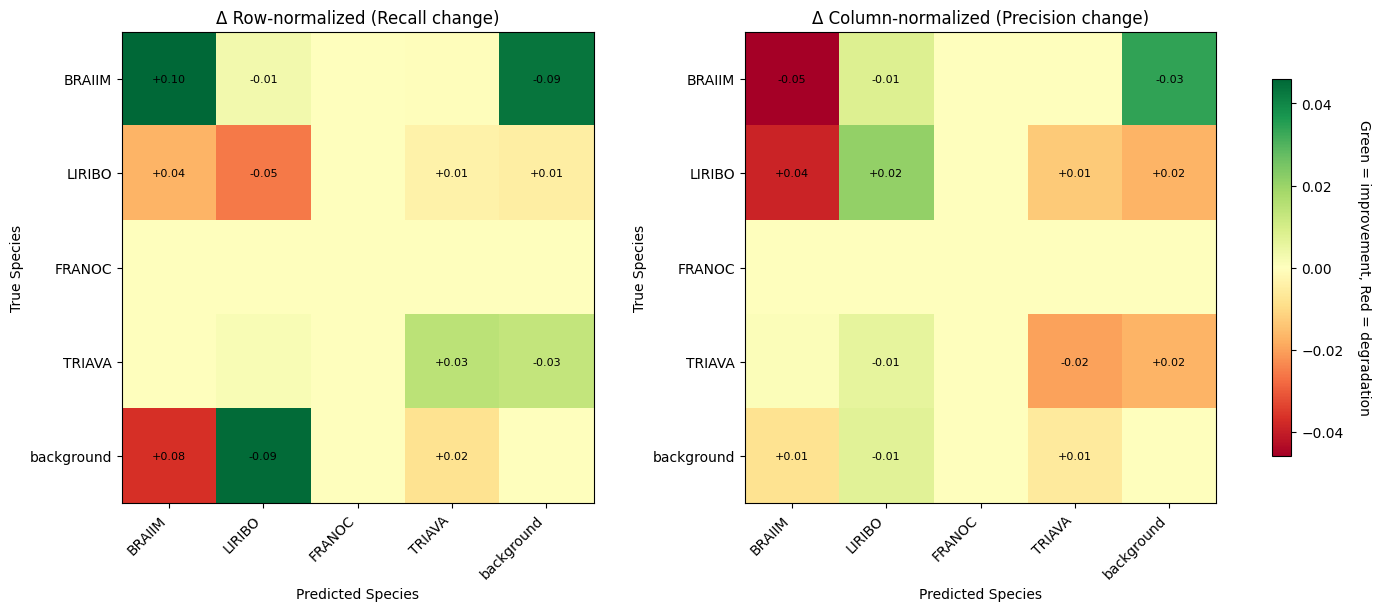

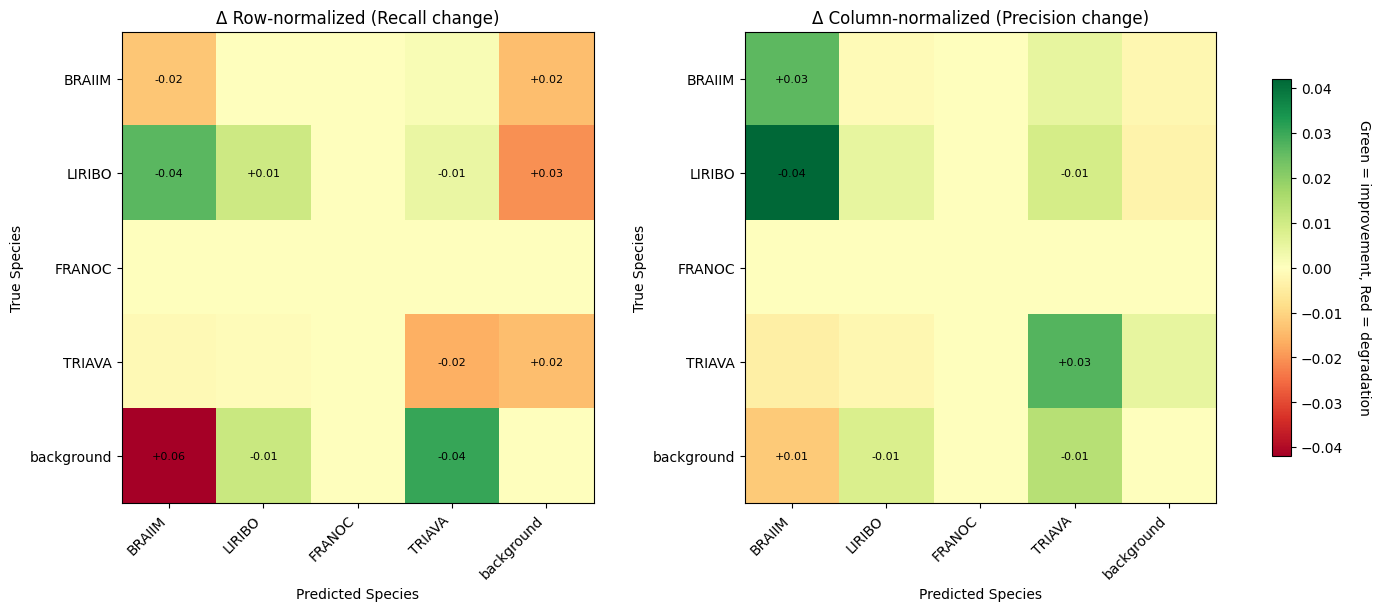

In [25]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/more_iterations1.json"
c1,c2 = give_confusion_infos(file)
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/more_iterations2.json"
c3,c4 = give_confusion_infos(file)
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/more_iterations5.json"
c5,c6 = give_confusion_infos(file)
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/more_iterations6.json"
c7,c8 = give_confusion_infos(file)
plot_confusion_matrix_differences(c1,c3, c2, c4, species)
plot_confusion_matrix_differences(c3,c5, c4, c6, species)
plot_confusion_matrix_differences(c5,c7, c6, c8, species)

### I'd say in the end this did not change anything

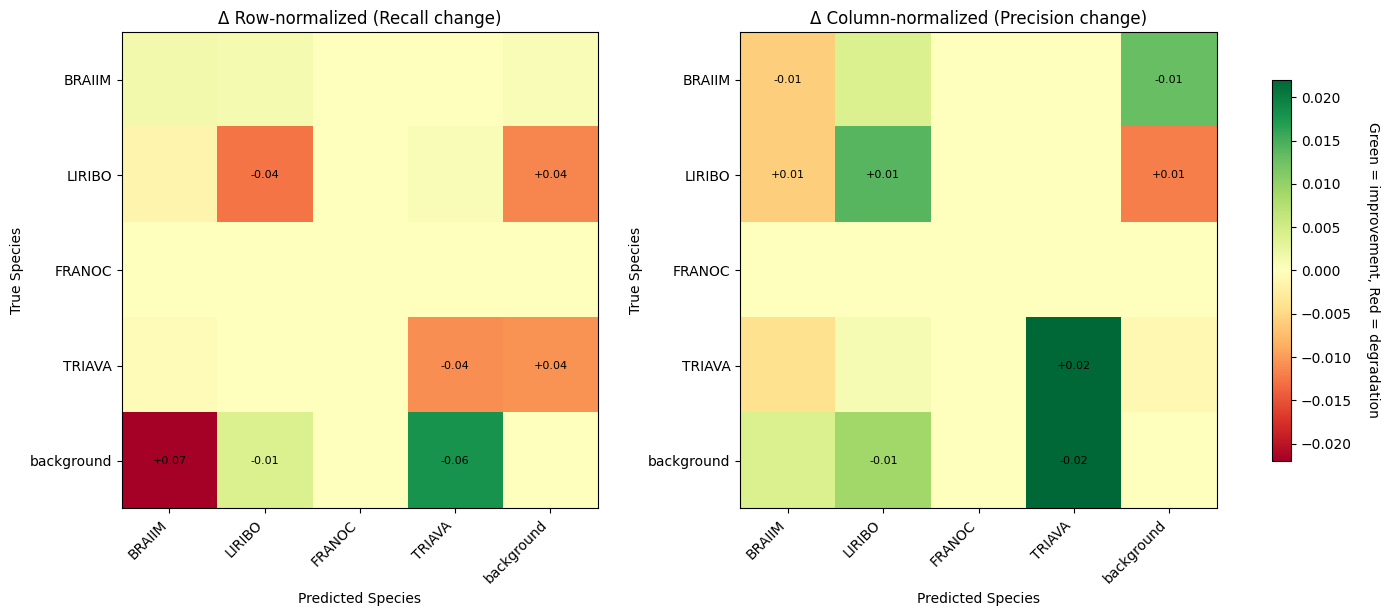

In [26]:
plot_confusion_matrix_differences(c1,c7, c2, c8, species)

### manual tests: fewer labels than supervised, predicting pseudo labels
instant good results

no improvements

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1313   52    0    1  266]
 [  13 1149    0   11  110]
 [   0    0    0    0    0]
 [   0    3    0 2082  539]
 [ 151   58    0  177    0]]


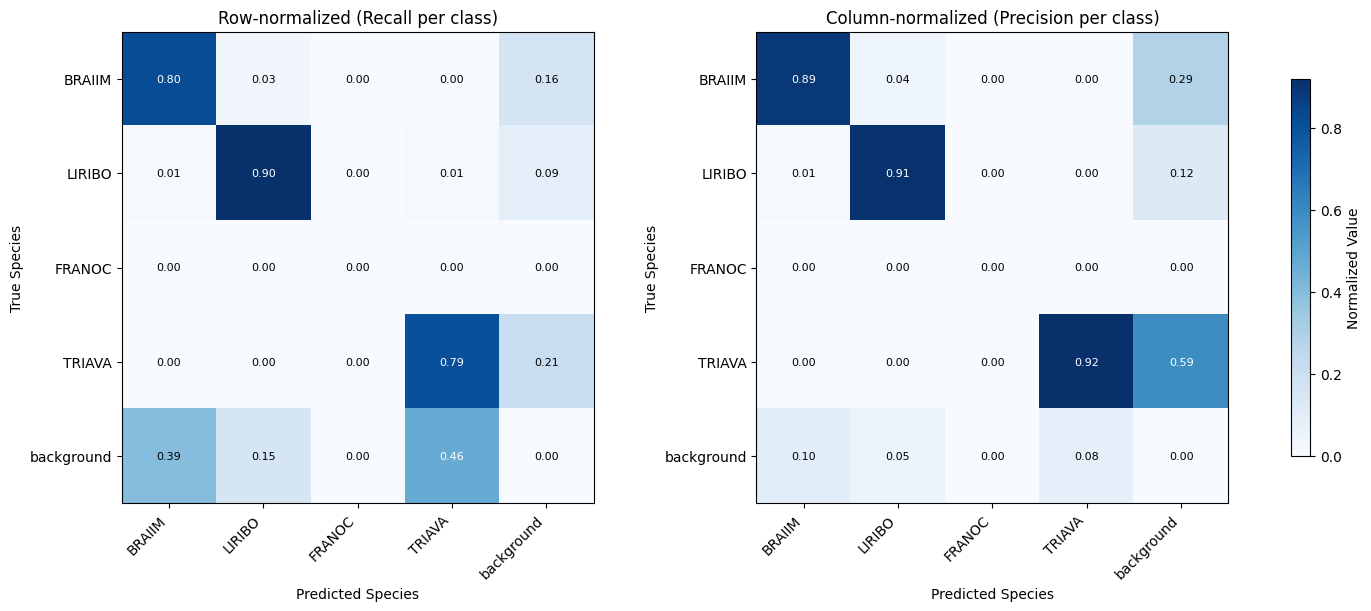

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1213   59    0    1  366]
 [  10 1184    0    7   75]
 [   0    0    0    0    0]
 [   0    2    0 1693  928]
 [  89   62    0   84    0]]


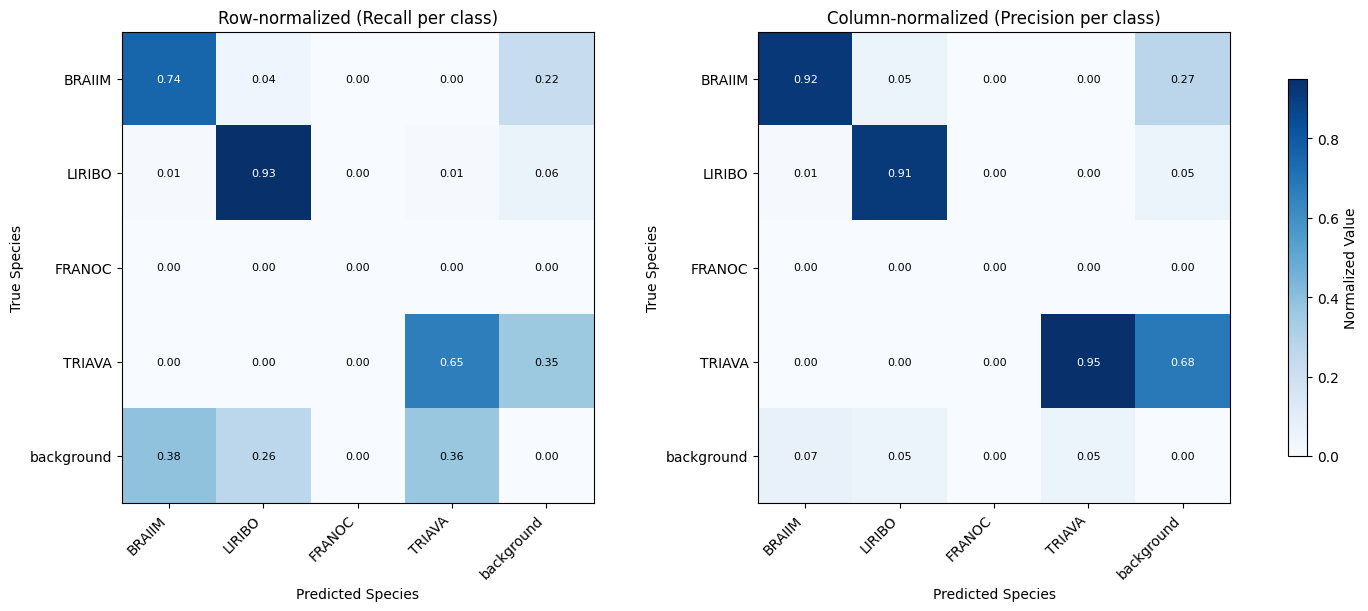

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1232  125    0    0  347]
 [  11 1197    0   10   62]
 [   0    0    0    0    0]
 [   0    5    0 1462 1159]
 [ 126   73    0   56    0]]


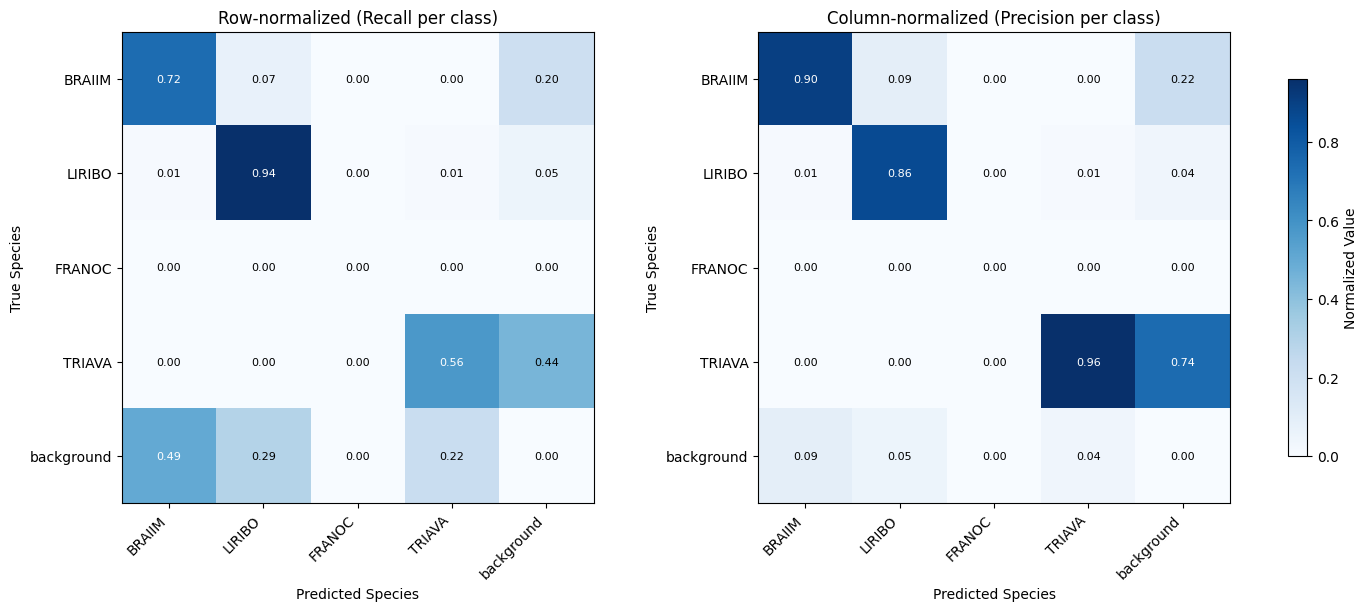

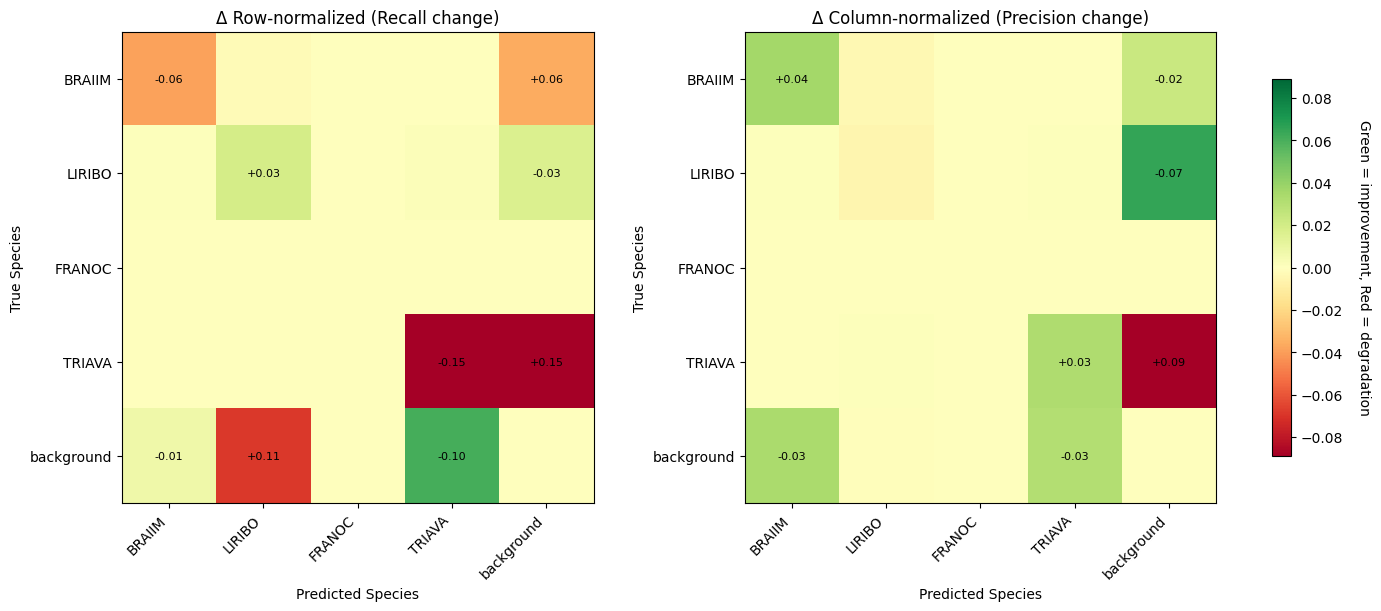

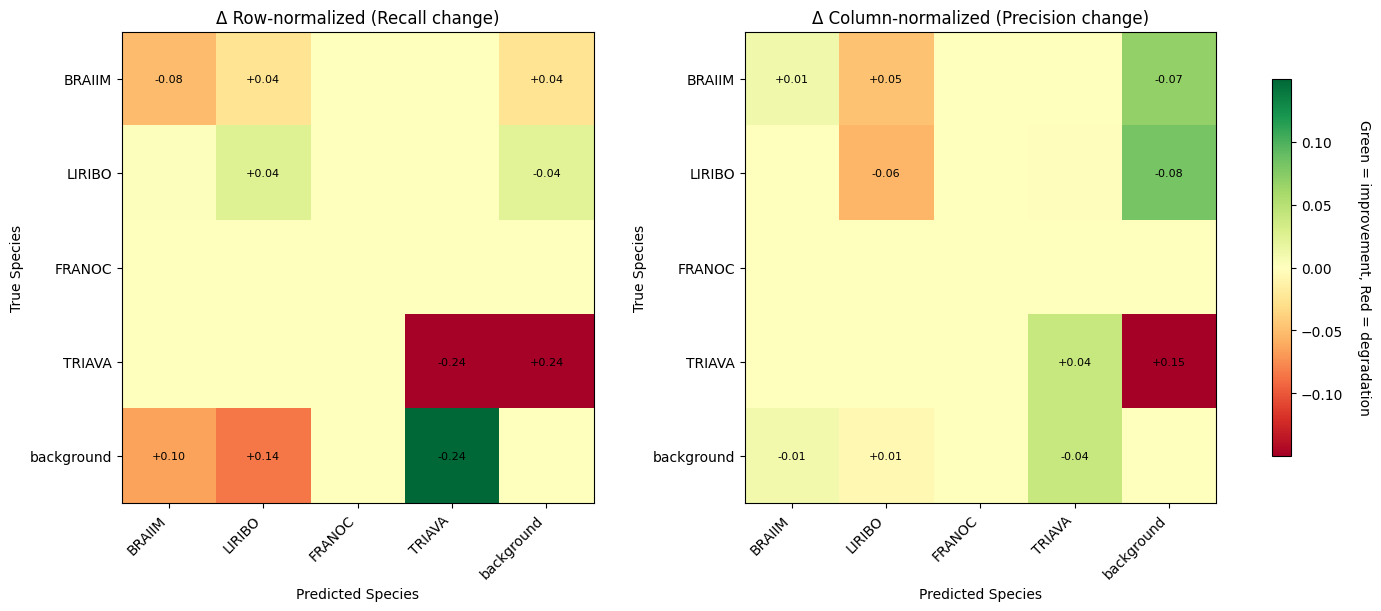

In [5]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/manual2.json"
c1,c2 = give_confusion_infos(file, 
                             output_path = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/first_manual.png")
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/manual3.json"
c3,c4 = give_confusion_infos(file)
file = "//user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/manual4.json"
c5,c6 = give_confusion_infos(file)
plot_confusion_matrix_differences(c1,c3, c2, c4, species)
plot_confusion_matrix_differences(c1,c5, c2, c6, species)


runs on unlabeled training set

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 801  182    0    1  778]
 [  10 1027    0    7  232]
 [   0    0    0    0    0]
 [   0   11    0  513 2108]
 [  99  120    0   17    0]]


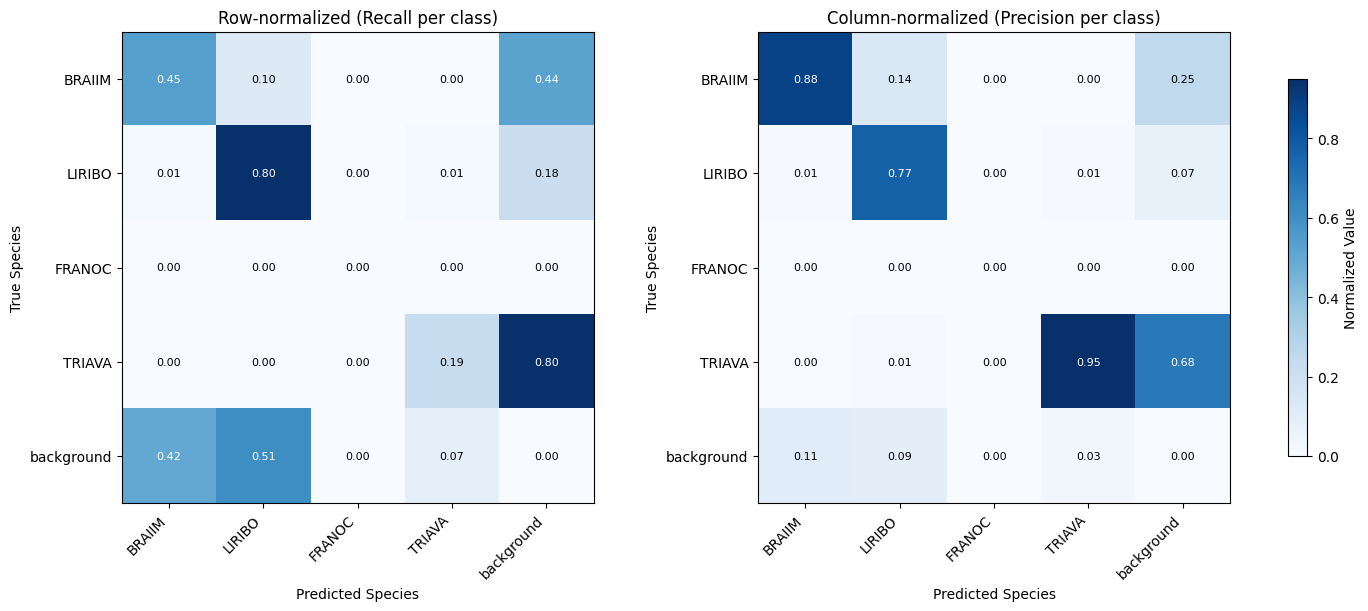

(array([[4.54597049e-01, 1.03291714e-01, 0.00000000e+00, 5.67536890e-04,
         4.41543700e-01],
        [7.83699060e-03, 8.04858934e-01, 0.00000000e+00, 5.48589342e-03,
         1.81818182e-01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 4.17933131e-03, 0.00000000e+00, 1.94908815e-01,
         8.00911854e-01],
        [4.19491525e-01, 5.08474576e-01, 0.00000000e+00, 7.20338983e-02,
         0.00000000e+00]]),
 array([[0.88021978, 0.1358209 , 0.        , 0.00185874, 0.24951892],
        [0.01098901, 0.76641791, 0.        , 0.01301115, 0.07440667],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.00820896, 0.        , 0.9535316 , 0.67607441],
        [0.10879121, 0.08955224, 0.        , 0.03159851, 0.        ]]))

In [6]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train/results.json"
give_confusion_infos(file)

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 931   29    0    6  648]
 [  48  941    0   11  318]
 [   0    0    0    0    0]
 [   2    4    0  575 2046]
 [ 125   59    0   20    0]]


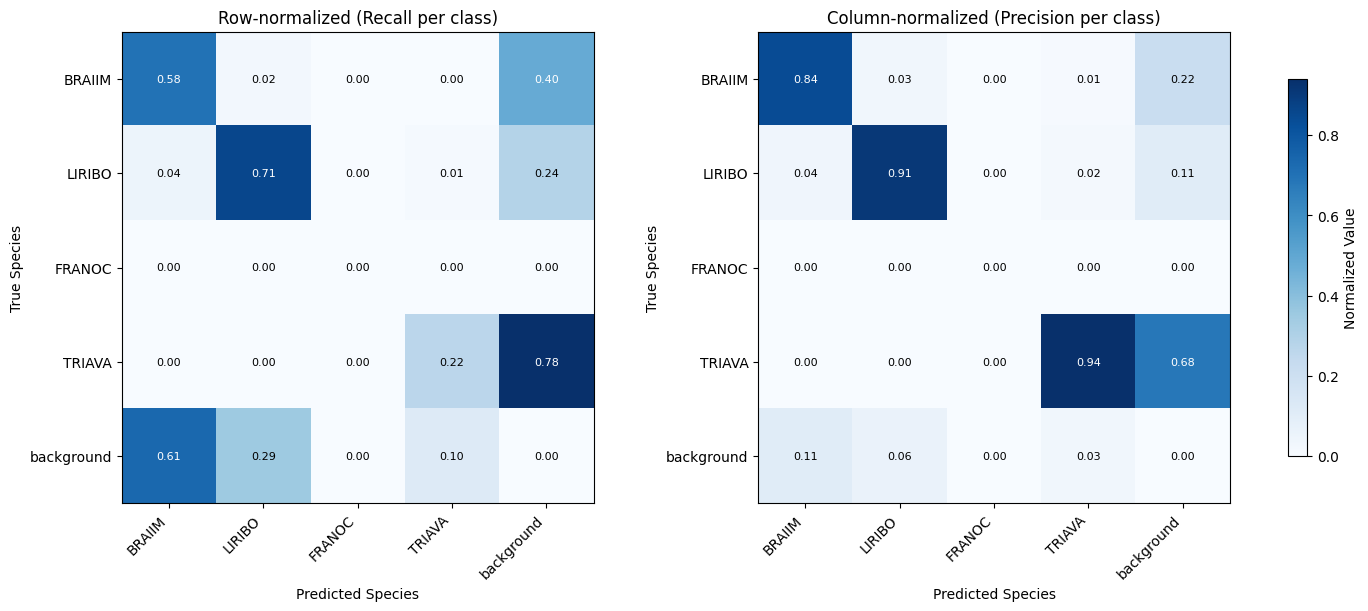

(array([[5.76827757e-01, 1.79677819e-02, 0.00000000e+00, 3.71747212e-03,
         4.01486989e-01],
        [3.64188164e-02, 7.13960546e-01, 0.00000000e+00, 8.34597876e-03,
         2.41274659e-01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [7.61324705e-04, 1.52264941e-03, 0.00000000e+00, 2.18880853e-01,
         7.78835173e-01],
        [6.12745098e-01, 2.89215686e-01, 0.00000000e+00, 9.80392157e-02,
         0.00000000e+00]]),
 array([[0.84177215, 0.02807357, 0.        , 0.00980392, 0.21513944],
        [0.04339964, 0.91093901, 0.        , 0.01797386, 0.10557769],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.00180832, 0.00387222, 0.        , 0.93954248, 0.67928287],
        [0.11301989, 0.0571152 , 0.        , 0.03267974, 0.        ]]))

In [ ]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train2/results.json"
give_confusion_infos(file)

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 949  336    0    0  630]
 [  64 1072    0    2  187]
 [   0    0    0    0    0]
 [  31   61    0  537 2084]
 [ 265  256    0    8    0]]


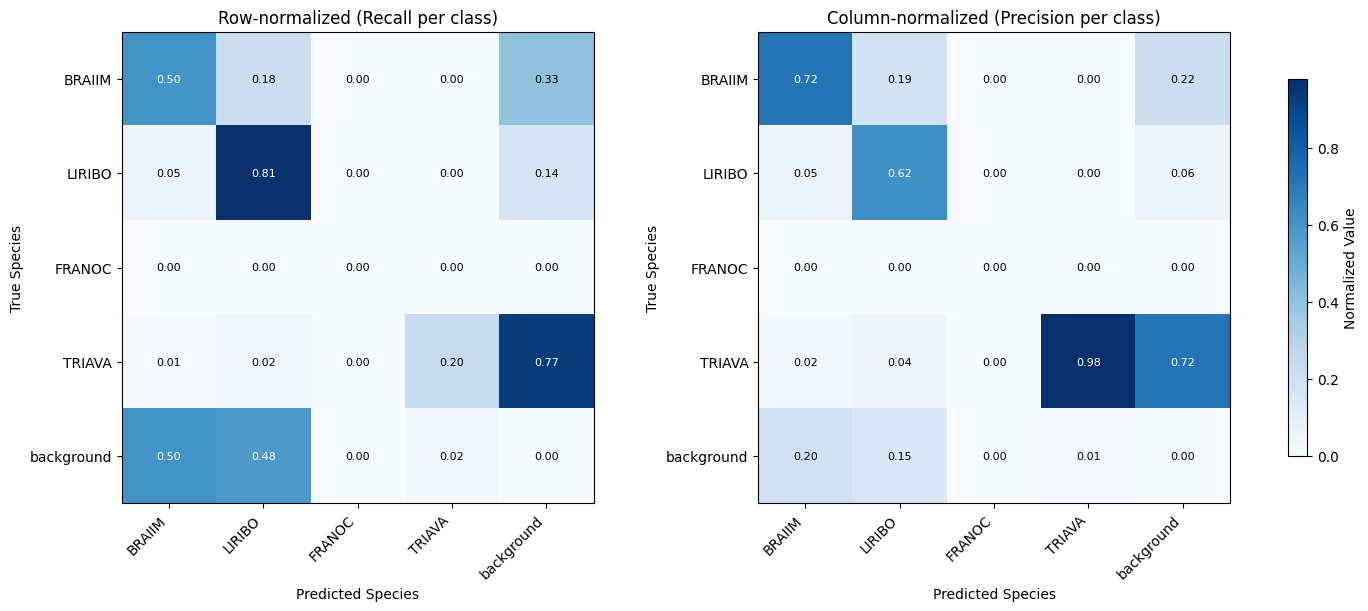

(array([[0.49556136, 0.17545692, 0.        , 0.        , 0.32898172],
        [0.04830189, 0.8090566 , 0.        , 0.00150943, 0.14113208],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.01142647, 0.02248433, 0.        , 0.19793586, 0.76815334],
        [0.50094518, 0.48393195, 0.        , 0.01512287, 0.        ]]),
 array([[0.7249809 , 0.19478261, 0.        , 0.        , 0.21716649],
        [0.04889228, 0.62144928, 0.        , 0.00365631, 0.06446053],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.0236822 , 0.03536232, 0.        , 0.98171846, 0.71837297],
        [0.20244461, 0.1484058 , 0.        , 0.01462523, 0.        ]]))

In [8]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train3/results.json"
give_confusion_infos(file)

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1127   32    0   14  452]
 [  57 1010    0   33  249]
 [   0    0    0    0    0]
 [   6   11    0  926 1695]
 [ 258  136    0   43    0]]


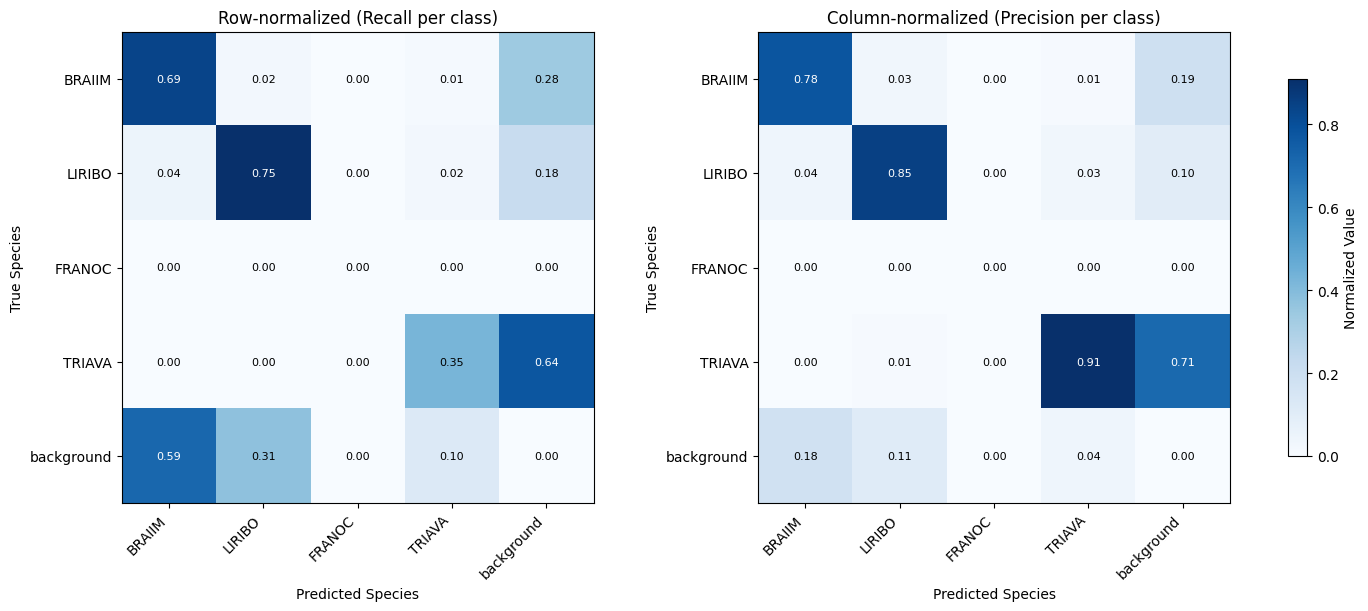

(array([[0.69353846, 0.01969231, 0.        , 0.00861538, 0.27815385],
        [0.04225352, 0.74870274, 0.        , 0.02446256, 0.18458117],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.00227445, 0.00416983, 0.        , 0.3510235 , 0.64253222],
        [0.59038902, 0.31121281, 0.        , 0.09839817, 0.        ]]),
 array([[0.77831492, 0.02691337, 0.        , 0.01377953, 0.18864775],
        [0.03936464, 0.84945332, 0.        , 0.03248031, 0.10392321],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.00414365, 0.00925147, 0.        , 0.91141732, 0.70742905],
        [0.1781768 , 0.11438183, 0.        , 0.04232283, 0.        ]]))

In [9]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train4/results.json"
give_confusion_infos(file)

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1099   73    0    0  480]
 [ 153  933    0    3  326]
 [   0    0    0    0    0]
 [  35   31    0  716 1905]
 [ 247  154    0   27    0]]


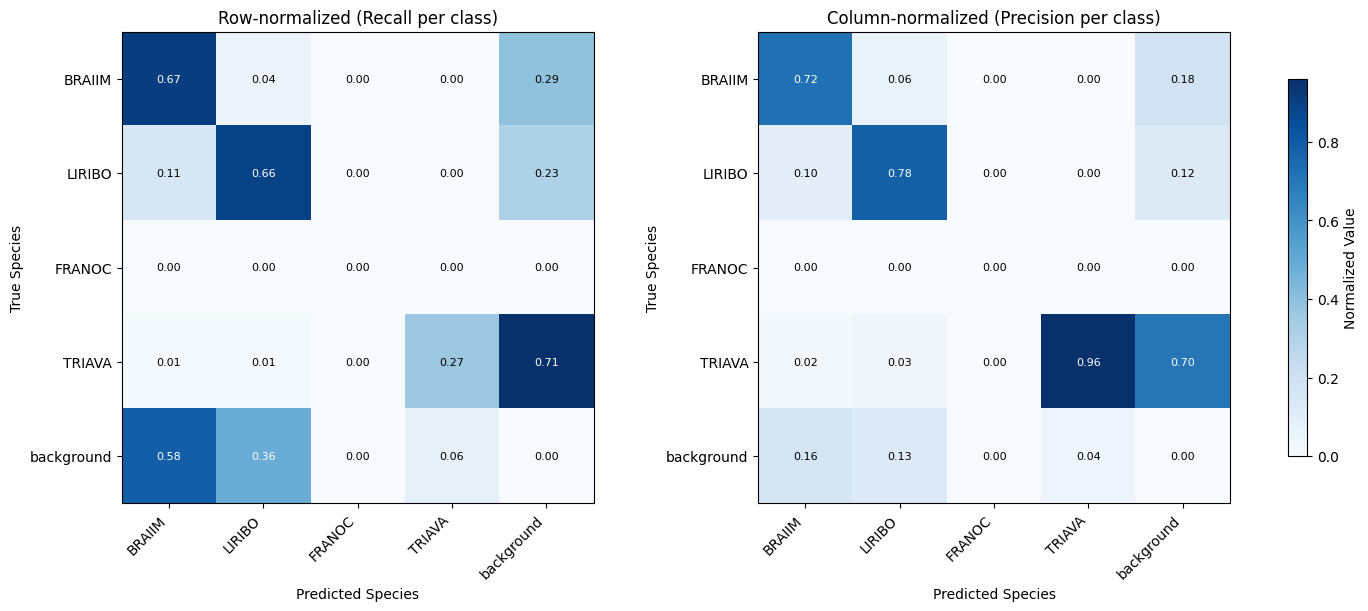

(array([[0.66525424, 0.04418886, 0.        , 0.        , 0.2905569 ],
        [0.10812721, 0.65936396, 0.        , 0.00212014, 0.23038869],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.01302568, 0.01153703, 0.        , 0.26646818, 0.70896911],
        [0.5771028 , 0.35981308, 0.        , 0.06308411, 0.        ]]),
 array([[0.71642764, 0.06129303, 0.        , 0.        , 0.17705644],
        [0.09973924, 0.78337531, 0.        , 0.00402145, 0.12025083],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.02281617, 0.02602855, 0.        , 0.95978552, 0.70269273],
        [0.16101695, 0.12930311, 0.        , 0.03619303, 0.        ]]))

In [ ]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train5/results.json"
give_confusion_infos(file)

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1085   32    0    6  494]
 [  38  966    0   23  293]
 [   0    0    0    0    0]
 [   1    6    0  587 2034]
 [ 230   93    0   22    0]]


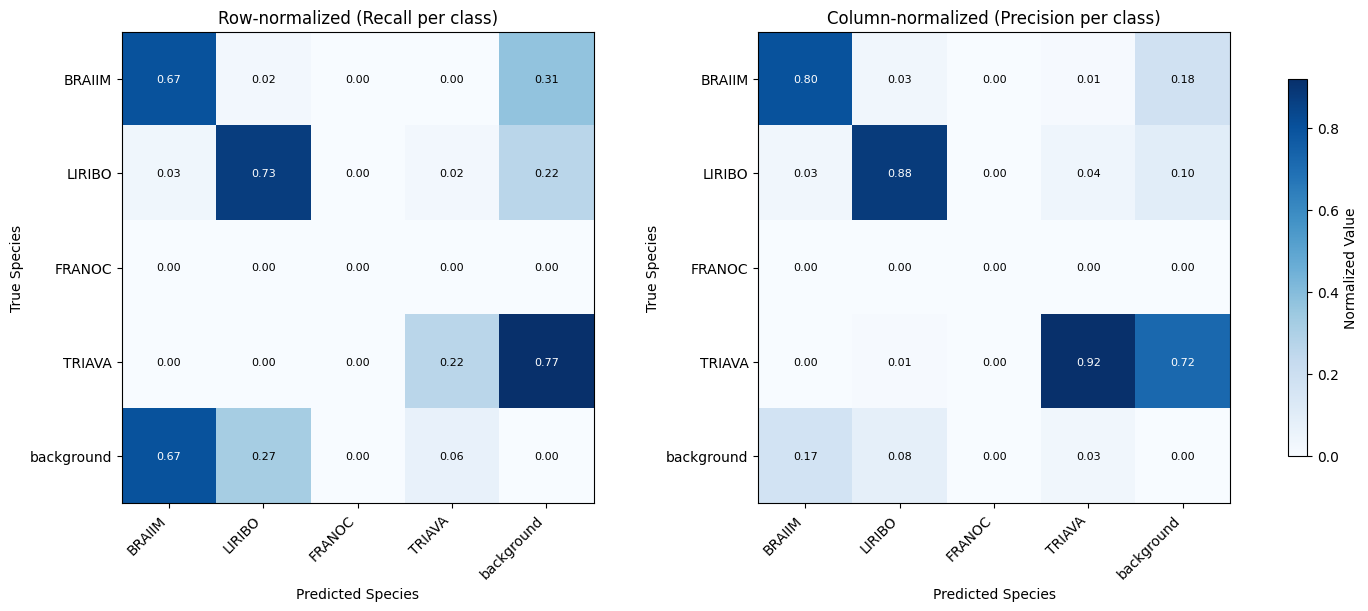

(array([[6.70995671e-01, 1.97897341e-02, 0.00000000e+00, 3.71057514e-03,
         3.05504020e-01],
        [2.87878788e-02, 7.31818182e-01, 0.00000000e+00, 1.74242424e-02,
         2.21969697e-01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [3.80517504e-04, 2.28310502e-03, 0.00000000e+00, 2.23363775e-01,
         7.73972603e-01],
        [6.66666667e-01, 2.69565217e-01, 0.00000000e+00, 6.37681159e-02,
         0.00000000e+00]]),
 array([[8.01329394e-01, 2.91704649e-02, 0.00000000e+00, 9.40438871e-03,
         1.75115207e-01],
        [2.80649926e-02, 8.80583409e-01, 0.00000000e+00, 3.60501567e-02,
         1.03863878e-01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [7.38552437e-04, 5.46946217e-03, 0.00000000e+00, 9.20062696e-01,
         7.21020915e-01],
        [1.69867061e-01, 8.47766636e-02, 0.00000000e+00, 3.44827586e-02,
         0.00000000e+00]]))

In [12]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train6/results.json"
give_confusion_infos(file)

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 924   20    0    0  655]
 [  50  958    0    0  302]
 [   0    0    0    0    0]
 [   3    5    0    3 2618]
 [ 186   93    0    0    0]]


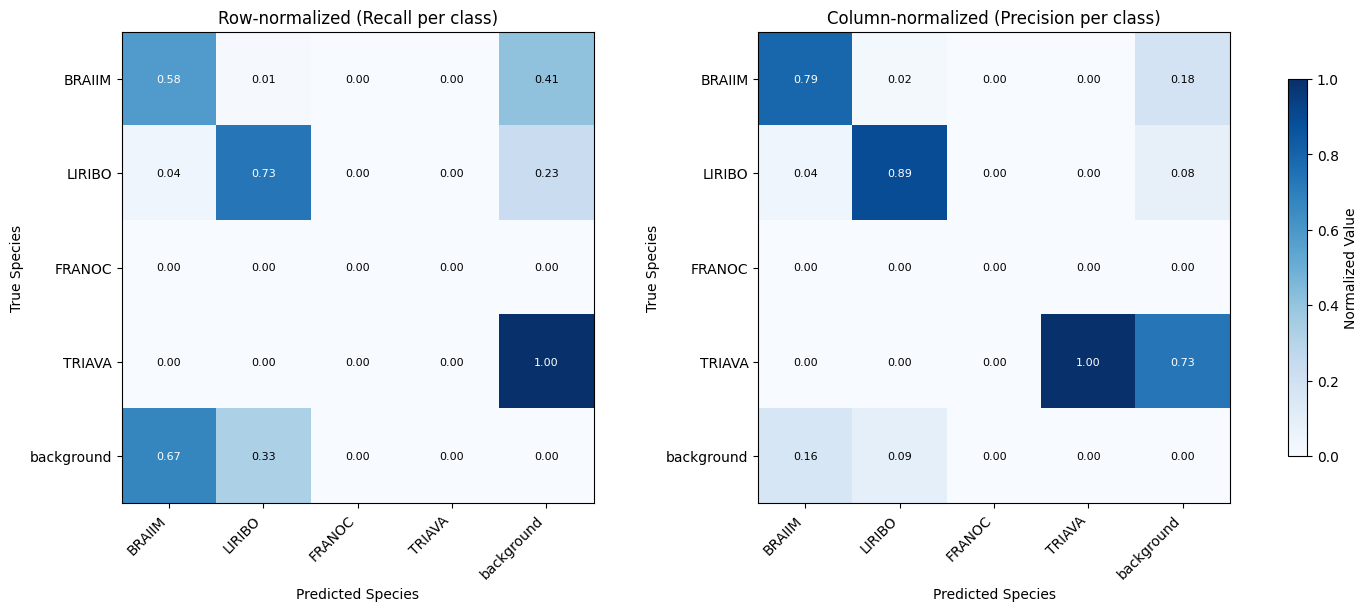

(array([[0.57786116, 0.01250782, 0.        , 0.        , 0.40963102],
        [0.03816794, 0.73129771, 0.        , 0.        , 0.23053435],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.00114112, 0.00190186, 0.        , 0.00114112, 0.9958159 ],
        [0.66666667, 0.33333333, 0.        , 0.        , 0.        ]]),
 array([[0.79449699, 0.01858736, 0.        , 0.        , 0.18321678],
        [0.04299226, 0.89033457, 0.        , 0.        , 0.08447552],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.00257954, 0.00464684, 0.        , 1.        , 0.73230769],
        [0.15993121, 0.08643123, 0.        , 0.        , 0.        ]]))

In [13]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train7/results.json"
give_confusion_infos(file)

### Runs on old imag processing with/without value threshold for whiteflies

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 894  178    0    4  685]
 [   9 1039    0    7  220]
 [   0    0    0    0    0]
 [   1    8    0  697 1924]
 [ 127  106    0   21    0]]


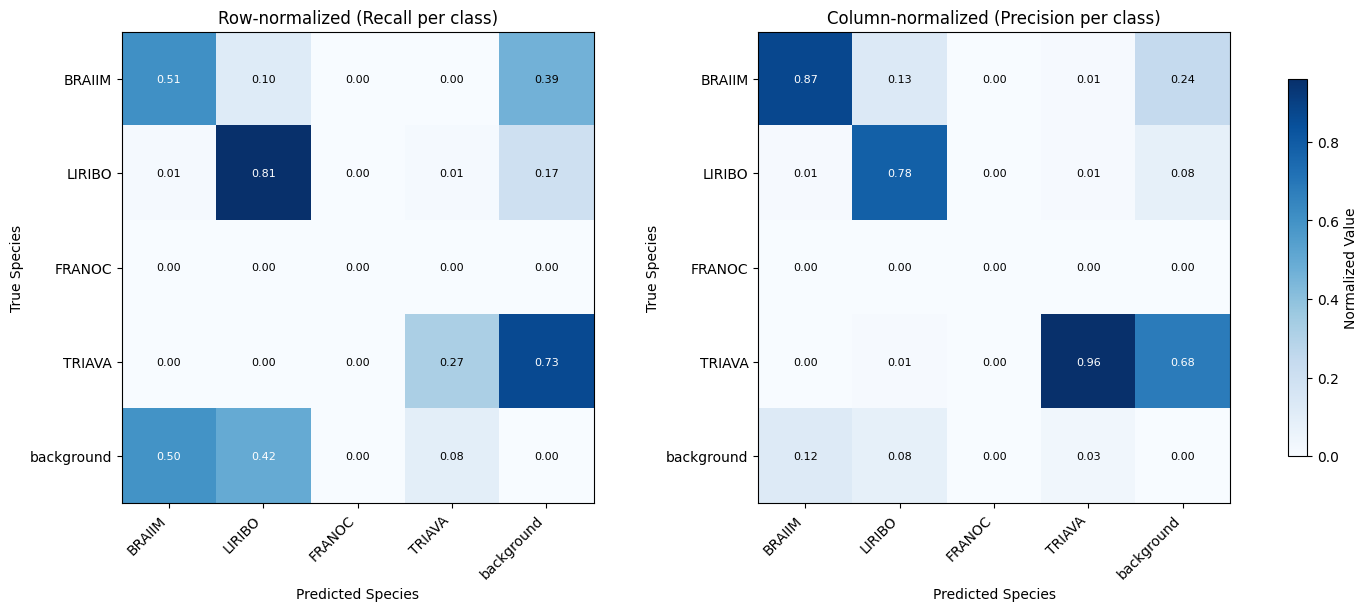

(array([[5.07666099e-01, 1.01078932e-01, 0.00000000e+00, 2.27143668e-03,
         3.88983532e-01],
        [7.05882353e-03, 8.14901961e-01, 0.00000000e+00, 5.49019608e-03,
         1.72549020e-01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [3.80228137e-04, 3.04182510e-03, 0.00000000e+00, 2.65019011e-01,
         7.31558935e-01],
        [5.00000000e-01, 4.17322835e-01, 0.00000000e+00, 8.26771654e-02,
         0.00000000e+00]]),
 array([[0.8671193 , 0.13373403, 0.        , 0.00548697, 0.24213503],
        [0.00872939, 0.78061608, 0.        , 0.00960219, 0.077766  ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.00096993, 0.00601052, 0.        , 0.95610425, 0.68009897],
        [0.12318138, 0.07963937, 0.        , 0.02880658, 0.        ]]))

In [7]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train8/results.json"
give_confusion_infos(file)

In [ ]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train9/results.json"
give_confusion_infos(file)

### Trained on manual labels with 1500 

In [ ]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train10/results.json"
give_confusion_infos(file)